In [88]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from typing import Iterable, List, Tuple, Optional, Sequence, Union
from scipy.ndimage import gaussian_filter1d
from utils import load_data, get_one_index
from matplotlib.colors import LinearSegmentedColormap

In [89]:
def plot_neuron_sorted_heatmaps(
    file_path: str,
    ana_tt: Iterable[str],
    ana_bt: Iterable[str],
):
    data = load_data(file_path)

    condition_list = [(tt, bt) for tt in ana_tt for bt in ana_bt]

    mats = []
    for rule_name, behavior_name in condition_list:
        tt_id, bt_id = get_one_index(rule_name, behavior_name)
        fr = data["firing"][tt_id][bt_id] # shape (n_neurons, n_trials, n_positions)
        fr = gaussian_filter1d(fr, sigma=20, axis=1, mode="nearest", truncate=3.0)
        fr_mean = np.mean(fr, axis=1) # shape (n_neurons, n_positions)
        denom = np.nanmax(np.abs(fr_mean), axis=1, keepdims=True)
        fr_norm = fr_mean / np.where(denom < 1e-8, 1.0, denom)
        mats.append(fr_norm)

    sort_mat = mats[0]
    peak_pos = np.nanargmax(sort_mat, axis=1)
    peak_val = np.nanmax(sort_mat, axis=1)
    sort_order = np.lexsort((peak_val, peak_pos))
    
    n_panels = len(condition_list)
    figsize = (3.0 * n_panels, 7.0)

    fig, axes = plt.subplots(1, n_panels, figsize=figsize, squeeze=False)
    axes = axes[0]

    ims = []
    sorted_mats = {}
    
    zones = data["zones"]
    # cmap = LinearSegmentedColormap.from_list(
    #     "blue_to_yellow", [(0, "blue"), (1, "yellow")]
    # )

    for id, ax in enumerate(axes):
        cond = condition_list[id]
        mat = mats[id][sort_order, :]
        sorted_mats[cond] = mat

        im = ax.imshow(
            mat,
            aspect="auto",
            interpolation="nearest",
            origin="upper",
            cmap="jet",
            # vmin=0.1,
            # vmax=0.99,
        )
        ims.append(im)
        
        for zone in zones:
            ax.axvline(zone[0], color="red", lw=1.5, zorder=1)
            ax.axvline(zone[1], color="red", lw=1.5, zorder=1)

        rule_name, behavior_name = cond
        ax.set_title(rule_name, fontsize=14)

        ax.set_xlabel("Position")
        ax.set_ylabel("Neuron (sorted)")

    # fig.colorbar(ims[-1], ax=axes, shrink=0.8)

    plt.tight_layout()
    fig.show()

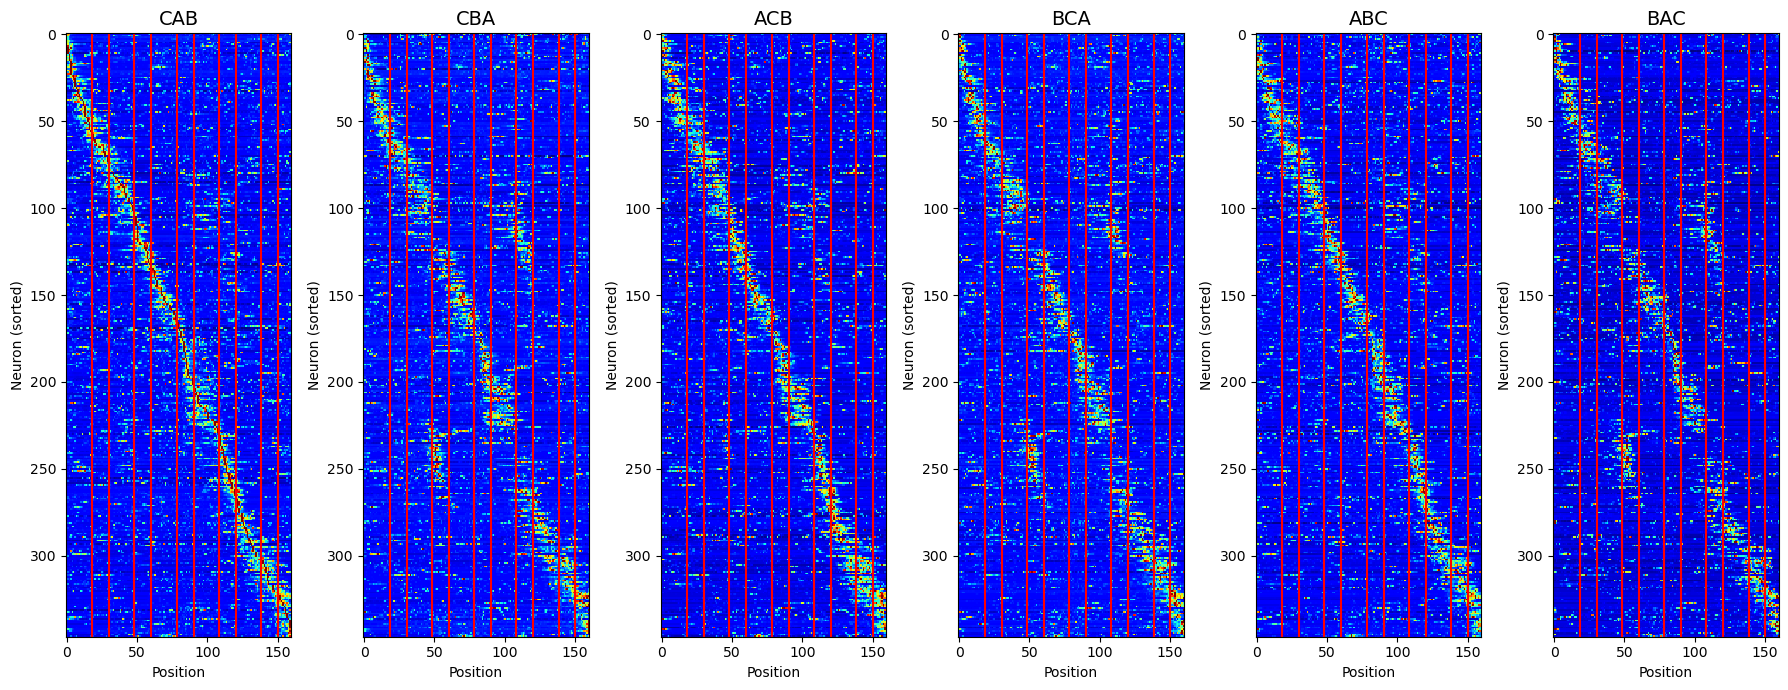

In [90]:
plot_neuron_sorted_heatmaps(
    file_path="../../data/HPC_2p/HP02/neuro_type_saveHP02_1_2024-12-23.mat",
    ana_tt=["CAB", "CBA", "ACB", "BCA", "ABC", "BAC"],
    ana_bt=["Correct"],
)

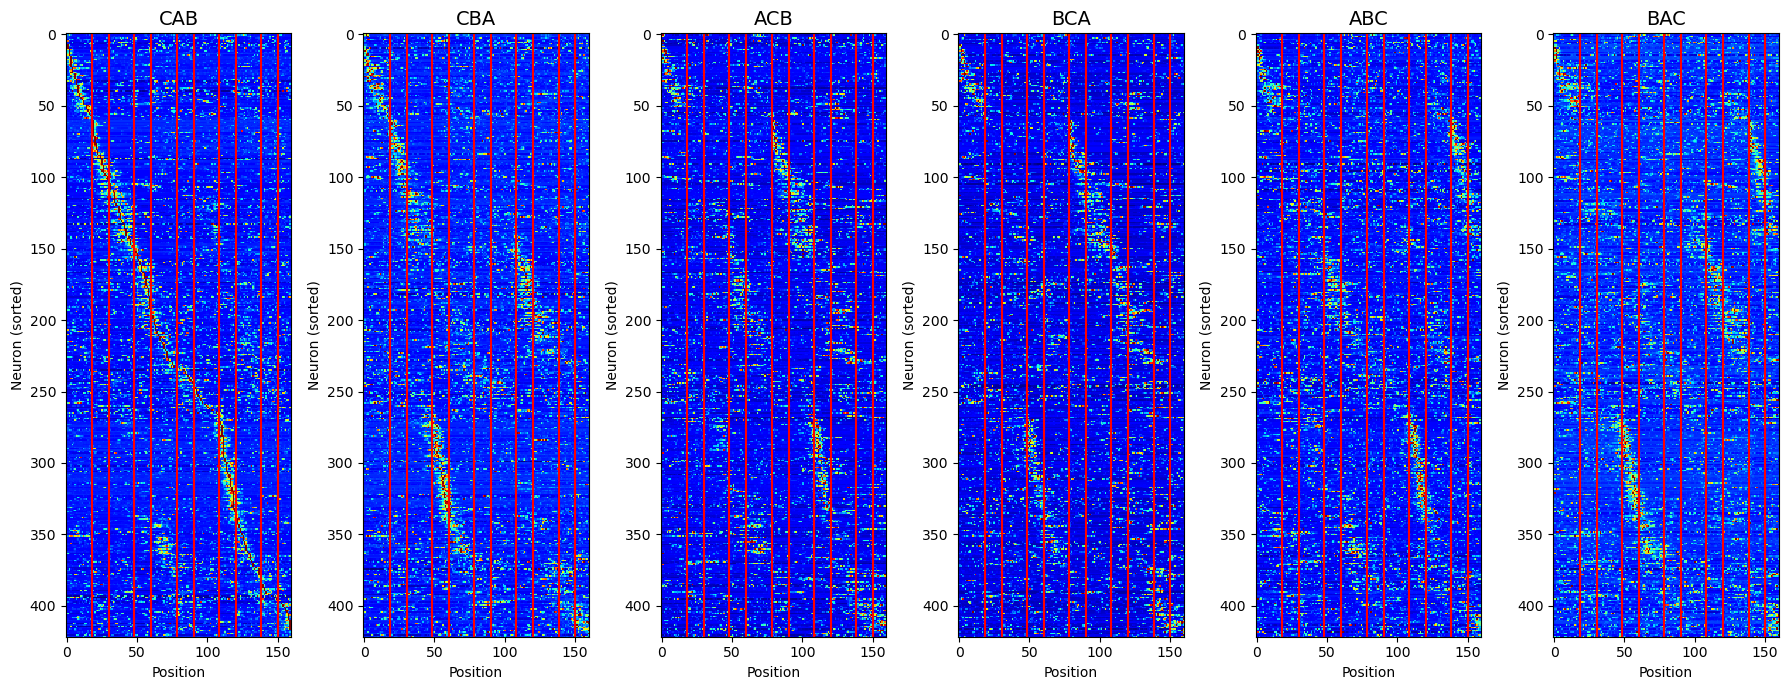

In [91]:
plot_neuron_sorted_heatmaps(
    file_path="../../data/HPC_2p/HP02/neuro_type_saveHP02_2_2024-12-29.mat",
    ana_tt=["CAB", "CBA", "ACB", "BCA", "ABC", "BAC"],
    ana_bt=["Correct"],
)